# Part 5 — Advanced Statistical & Multivariate Models

**Series:** *Time Series Analysis in Python — from Statistical Modeling to Machine Learning*

Part 4 closed with two loose ends. First, its ARIMA residuals were **heavy-tailed
and volatility-clustered** — the mean was captured but the *variance* was not.
Second, the only thing that improved the forecast was **exogenous information**
(energy), yet a univariate model has no way to use another series' dynamics. Part
5 resolves both, and broadens the classical toolkit to its full extent.

### What you will learn
1. **Volatility modelling** — ARCH/GARCH for the changing variance Part 4 diagnosed
2. **State-space models & the Kalman filter** — Unobserved Components, a model-based decomposition
3. **VAR** — vector autoregression: many series predicting each other, with **impulse responses** and **Granger causality**
4. **Cointegration & VECM** — modelling a long-run equilibrium between non-stationary series
5. **Prophet** — a decomposable additive model (trend + seasonality + holidays)
6. A benchmark of these advanced methods against Parts 3–4's winners

### Dataset & continuity
Still `monthly_price.csv` (356 months, 1992–2021), same **24-month hold-out** on
the **Food Price Index**. New libraries: `arch` (GARCH) and `prophet`, alongside
`statsmodels` for the state-space and multivariate machinery.

## 0. Setup, data, and shared helpers

In [1]:
import warnings, logging, io, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.simplefilter("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)
logging.getLogger("prophet").setLevel(logging.ERROR)

from arch import arch_model
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM, select_coint_rank
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
with contextlib.redirect_stderr(io.StringIO()):     # hide the harmless plotly notice
    from prophet import Prophet

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "font.size": 11, "lines.linewidth": 1.6,
})
PALETTE = ["#2b6cb0", "#c05621", "#2f855a", "#6b46c1", "#b83280", "#718096"]

raw = pd.read_csv("monthly_price.csv")
dates = pd.to_datetime(raw["YEAR"].astype(str) + "-" + raw["MONTH"], format="%Y-%b")
df = raw.drop(columns=["ID", "YEAR", "MONTH", "TIME"]).copy()
df.index = dates; df.index.name = "date"; df = df.asfreq("MS")

H = 24
y = df["Food_Price_Index"]; train, test = y.iloc[:-H], y.iloc[-H:]

def rmse(a, p): return np.sqrt(np.mean((np.asarray(a) - np.asarray(p)) ** 2))
def mae(a, p):  return np.mean(np.abs(np.asarray(a) - np.asarray(p)))
def mape(a, p): return np.mean(np.abs((np.asarray(a) - np.asarray(p)) / np.asarray(a))) * 100
def score(name, a, p):
    return {"model": name, "MAE": round(mae(a, p), 3),
            "RMSE": round(rmse(a, p), 3), "MAPE%": round(mape(a, p), 2)}
print("ready — train", len(train), "| test", len(test))

ready — train 332 | test 24


## 1. Where these models fit

The classical families we've met each describe *one* aspect of a series:

- **ETS / smoothing** (Part 3) — components (level, trend, season) of the **mean**.
- **ARIMA** (Part 4) — autocorrelation of the **mean**.

Part 5 adds three orthogonal capabilities:

- **GARCH** models the **variance**, not the mean — for series whose *volatility*
  itself moves (finance, prices in crisis).
- **State-space / VAR / VECM** move from one series to a **system** of series,
  capturing how they drive each other and share long-run equilibria.
- **Prophet** re-imagines decomposition as a flexible, automatic **additive
  regression** — a pragmatic default for business data.

Together they turn "energy seems to matter for food" into models we can actually
estimate and interpret.

## 2. Volatility modelling — ARCH & GARCH

Part 4's residual diagnostics showed **volatility clustering**: calm stretches and
turbulent stretches (2008, 2020), with heavy tails. Standard ARIMA assumes
**constant** variance and cannot represent this. **ARCH/GARCH** models the
**conditional variance** as itself a time series.

Volatility models work on **returns**, not levels. We use monthly **log-returns**
of the Food Price Index (×100 for percentage points).

- **ARCH(q):** today's variance depends on recent **squared shocks**:
  $\sigma_t^2 = \omega + \sum_{i=1}^q \alpha_i\,\varepsilon_{t-i}^2$.
- **GARCH(p,q):** add dependence on recent **past variances** — far more
  parsimonious: $\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2$.

First, a formal check that ARCH effects even exist — the **ARCH-LM test** (H₀: no
ARCH effect).

In [2]:
ret = 100 * np.log(df["Food_Price_Index"]).diff().dropna()
lm_stat, lm_p, f_stat, f_p = het_arch(ret, nlags=12)
print(f"ARCH-LM test:  LM p-value = {lm_p:.4g}")
print("=> " + ("strong ARCH effects present — GARCH is warranted"
                if lm_p < 0.05 else "no ARCH effects"))

ARCH-LM test:  LM p-value = 1.415e-05
=> strong ARCH effects present — GARCH is warranted


The test decisively rejects constant variance, so we fit a **GARCH(1,1)** with a
**Student-t** error distribution (to accommodate the heavy tails Part 4 found).

In [3]:
ret_tr = ret.iloc[:-H]
garch = arch_model(ret_tr, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
print(garch.summary().tables[1])

                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.0234      0.166      0.141      0.888 [ -0.302,  0.348]


The key parameters are **α** (reaction to the last shock) and **β** (persistence
of past variance). Their sum α+β measures how long volatility shocks linger —
close to 1 means very persistent. Let's plot the estimated **conditional
volatility**: the model's month-by-month view of risk.

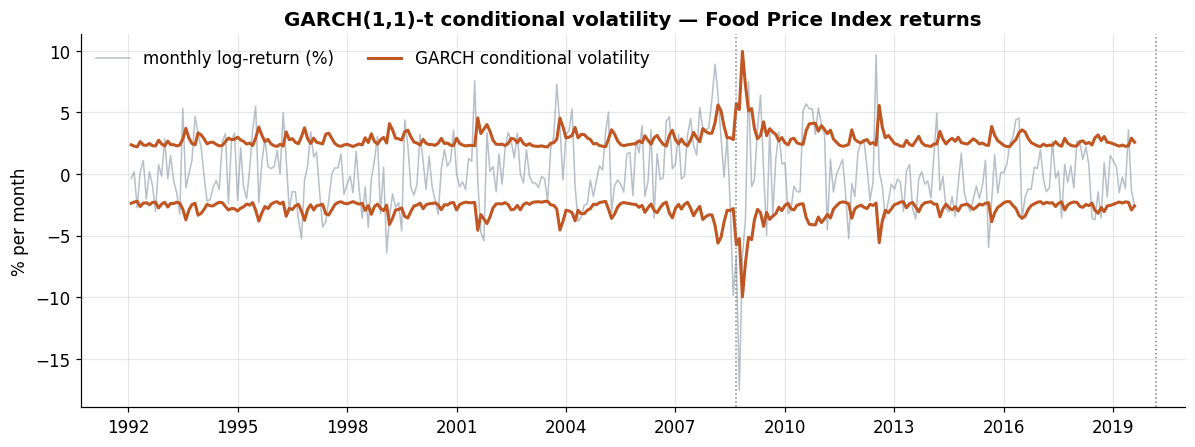

α + β = 0.650  (volatility persistence)


In [4]:
cond_vol = garch.conditional_volatility
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(ret_tr.index, ret_tr, color=PALETTE[5], alpha=0.5, lw=1, label="monthly log-return (%)")
ax.plot(cond_vol.index, cond_vol, color=PALETTE[1], lw=2, label="GARCH conditional volatility")
ax.plot(cond_vol.index, -cond_vol, color=PALETTE[1], lw=2)
for yr in ["2008-09-01", "2020-03-01"]:
    ax.axvline(pd.Timestamp(yr), color="grey", ls=":", lw=1)
ax.set_title("GARCH(1,1)-t conditional volatility — Food Price Index returns")
ax.set_ylabel("% per month"); ax.legend(frameon=False, ncol=2)
ax.xaxis.set_major_locator(mdates.YearLocator(3))
plt.tight_layout(); plt.show()
print(f"α + β = {garch.params['alpha[1]'] + garch.params['beta[1]']:.3f}  (volatility persistence)")

The volatility envelope **widens exactly at the crises** and narrows in calm
periods — precisely the clustering ARIMA could not capture. GARCH is what you add
when you care about **risk and interval width**, not just the point forecast; it
also produces a **variance forecast** that fans out realistically.

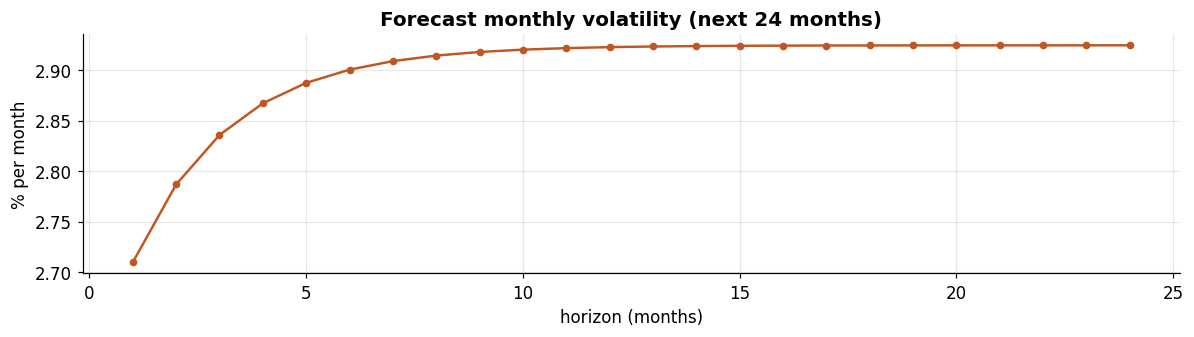

ARCH-LM on standardized residuals p-value: 0.664 -> clustering removed ✓


In [5]:
vf = garch.forecast(horizon=H, reindex=False)
vol_fc = np.sqrt(vf.variance.values[-1])
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(range(1, H + 1), vol_fc, color=PALETTE[1], marker="o", ms=4)
ax.set_title("Forecast monthly volatility (next 24 months)")
ax.set_xlabel("horizon (months)"); ax.set_ylabel("% per month")
plt.tight_layout(); plt.show()

std_resid = garch.resid / garch.conditional_volatility
p_after = het_arch(std_resid.dropna(), nlags=12)[1]
print("ARCH-LM on standardized residuals p-value:", round(p_after, 3),
      "-> " + ("clustering removed ✓" if p_after > 0.05 else "clustering remains"))

## 3. State-space models & the Kalman filter

A **state-space model** describes a series as noisy observations of **unobserved
states** — a level, a trend, a seasonal pattern — that evolve stochastically over
time. The **Kalman filter** is the recursive engine that estimates those hidden
states: at each step it *predicts* the next state, then *updates* the prediction
with the new observation, balancing the two by their relative uncertainty. This
framework actually *generalizes* both ETS and ARIMA (statsmodels fits them all as
state-space models under the hood).

The **Unobserved Components** model lets us specify the pieces directly. We fit a
**local linear trend + stochastic seasonal** model — a *model-based* cousin of the
STL decomposition from Part 2, but one that yields forecasts and uncertainty.

Unobserved Components — AIC = 1549.6


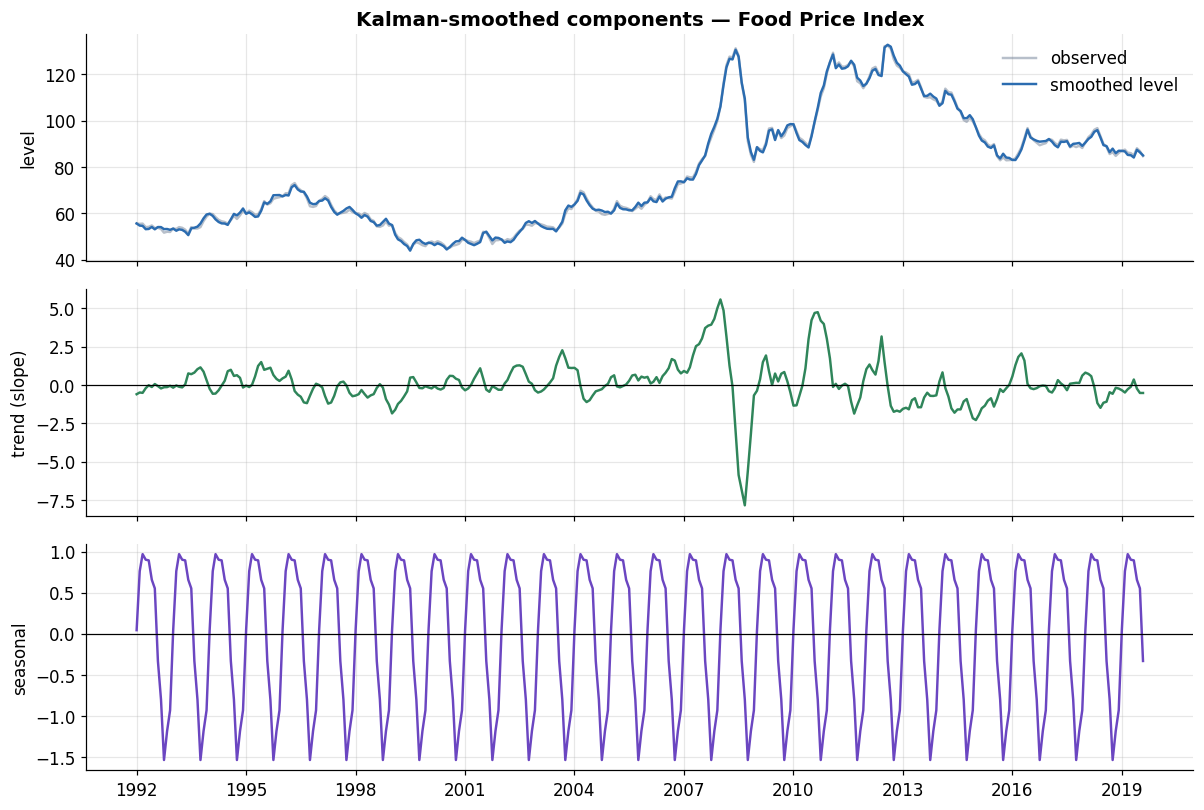

In [6]:
uc = UnobservedComponents(train, level="local linear trend", seasonal=12).fit(disp=False)
print(f"Unobserved Components — AIC = {uc.aic:.1f}")

comp = uc.states.smoothed
fig, axes = plt.subplots(3, 1, figsize=(11, 7.5), sharex=True)
axes[0].plot(train.index, train, color=PALETTE[5], alpha=0.5, label="observed")
axes[0].plot(comp.index, comp["level"], color=PALETTE[0], label="smoothed level")
axes[0].set_title("Kalman-smoothed components — Food Price Index")
axes[0].legend(frameon=False); axes[0].set_ylabel("level")
axes[1].plot(comp.index, comp["trend"], color=PALETTE[2]); axes[1].axhline(0, color="k", lw=.8)
axes[1].set_ylabel("trend (slope)")
axes[2].plot(comp.index, comp["seasonal"], color=PALETTE[3]); axes[2].axhline(0, color="k", lw=.8)
axes[2].set_ylabel("seasonal"); axes[2].xaxis.set_major_locator(mdates.YearLocator(3))
plt.tight_layout(); plt.show()

The filter recovers a smooth **level**, a slowly-varying **trend** (its slope
swings positive into 2008 and negative afterwards — the boom and bust as a single
evolving parameter), and a small **seasonal** term consistent with the light
seasonality we've seen throughout. Forecasting is a natural extension of the same
recursion, with prediction intervals from the state uncertainty.

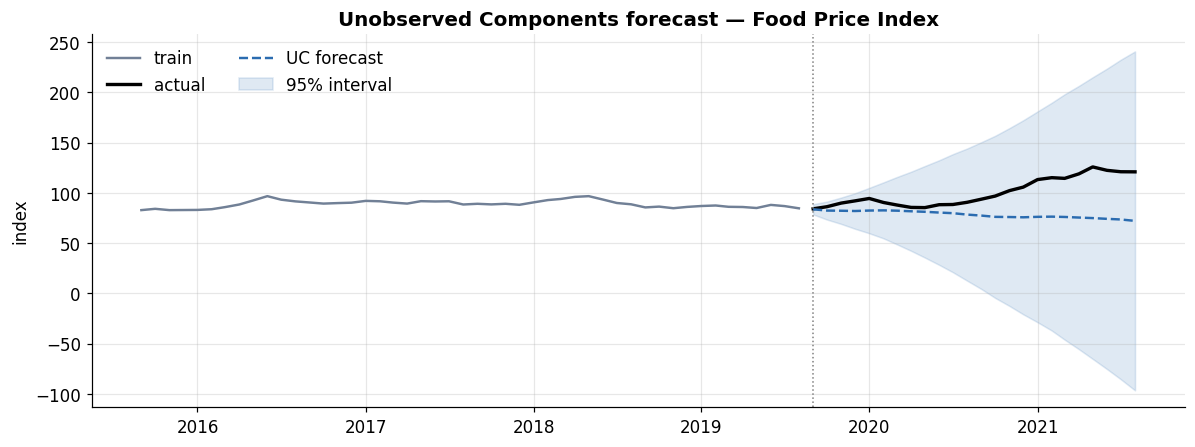

{'model': 'Unobserved Components', 'MAE': np.float64(22.124), 'RMSE': np.float64(28.012), 'MAPE%': np.float64(20.11)}


In [7]:
uc_fc = uc.get_forecast(H)
uc_mean = uc_fc.predicted_mean
uc_ci = uc_fc.conf_int(alpha=0.05)
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(train.index[-48:], train.iloc[-48:], color=PALETTE[5], label="train")
ax.plot(test.index, test, color="black", lw=2.2, label="actual")
ax.plot(uc_mean.index, uc_mean, color=PALETTE[0], ls="--", label="UC forecast")
ax.fill_between(uc_ci.index, uc_ci.iloc[:, 0], uc_ci.iloc[:, 1],
                color=PALETTE[0], alpha=0.15, label="95% interval")
ax.axvline(test.index[0], color="grey", lw=1, ls=":")
ax.set_title("Unobserved Components forecast — Food Price Index")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()
print(score("Unobserved Components", test, uc_mean.values))

## 4. Vector Autoregression (VAR)

Everything so far modelled **one** series. A **VAR** models a **system**: each
variable is regressed on lags of **itself and every other variable**, so the model
captures how the series feed back on one another. VAR requires the inputs to be
**stationary**, so — as in Part 2 — we work with **log-returns**.

We build a three-variable system that carries Part 4's thread forward:
**Food**, **Energy**, and **Urea** (fertilizer) prices.

In [8]:
sys_levels = np.log(df[["Food_Price_Index", "Energy_Price_Index", "Urea_Price"]])
sys_ret = (sys_levels.diff().dropna() * 100)
sys_tr = sys_ret.iloc[:-H]

var_model = VAR(sys_tr)
order_sel = var_model.select_order(maxlags=8)
print(order_sel.summary())
var_res = var_model.fit(maxlags=8, ic="aic")
print("\nSelected lag (AIC):", var_res.k_ar)

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0       10.97       11.01   5.821e+04       10.99
1       10.72      10.86*   4.529e+04      10.78*
2      10.72*       10.96  4.513e+04*       10.82
3       10.75       11.11   4.684e+04       10.89
4       10.76       11.22   4.731e+04       10.95
5       10.78       11.34   4.820e+04       11.01
6       10.80       11.47   4.901e+04       11.07
7       10.82       11.59   4.980e+04       11.12
8       10.85       11.73   5.151e+04       11.20
-------------------------------------------------

Selected lag (AIC): 2


### Impulse Response Functions (IRF)

A VAR's most illuminating output is the **impulse response**: if one variable
receives a one-time **shock**, how do all the variables respond over the following
months? The shaded bands are confidence intervals — where they straddle zero, the
response is not statistically distinguishable from nothing.

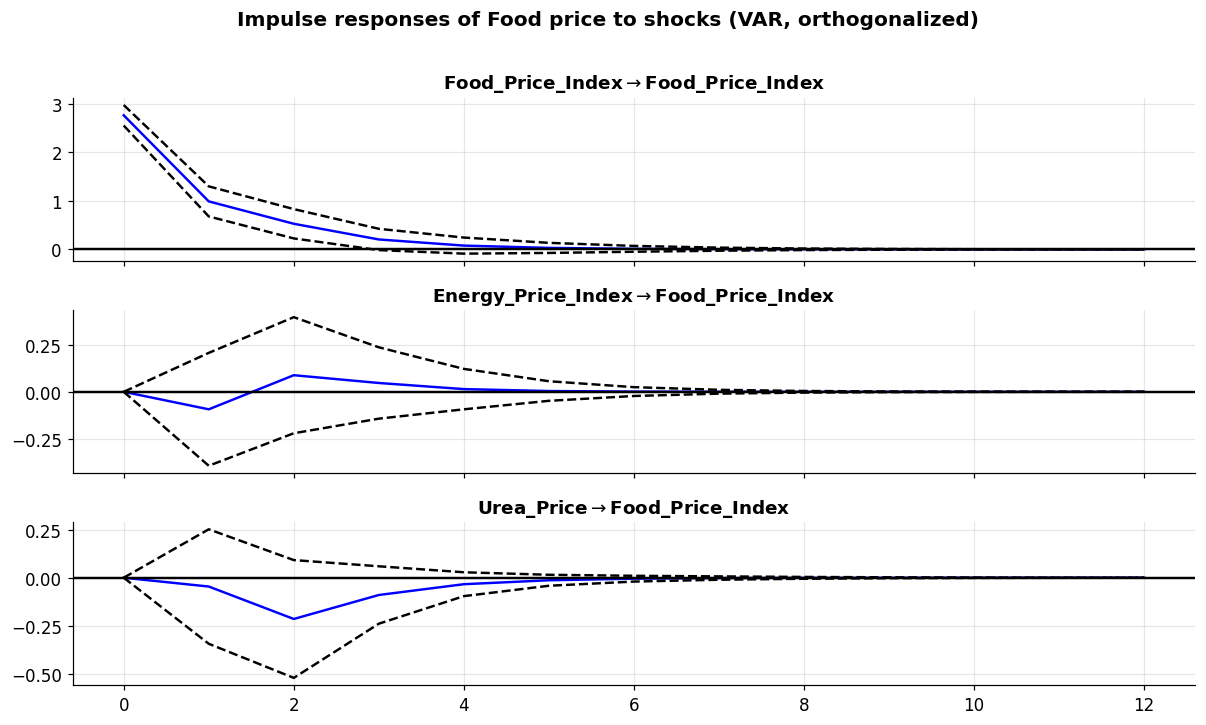

In [9]:
irf = var_res.irf(12)
fig = irf.plot(orth=True, response="Food_Price_Index",
               figsize=(11, 6.5), signif=0.05)
fig.suptitle("Impulse responses of Food price to shocks (VAR, orthogonalized)",
             fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### Granger causality — predictive precedence

**Granger causality** asks a precise question: *does the past of X help predict Y
beyond Y's own past?* If yes, X "Granger-causes" Y. Crucially this is **predictive
precedence, not mechanism** — it does not prove X *causes* Y in any physical
sense. We test both directions.

In [10]:
pairs = [("Energy_Price_Index", "Food_Price_Index"),
         ("Urea_Price",          "Food_Price_Index"),
         ("Food_Price_Index",    "Energy_Price_Index")]
rows = []
for cause, effect in pairs:
    t = var_res.test_causality(effect, [cause], kind="f")
    rows.append({"cause -> effect": f"{cause} -> {effect}",
                 "F p-value": round(t.pvalue, 4),
                 "Granger-causal @0.05": "yes" if t.pvalue < 0.05 else "no"})
pd.DataFrame(rows)

,cause -> effect,F p-value,Granger-causal @0.05
0,Energy_Price_Index -> Food_Price_Index,0.5200,no
1,Urea_Price -> Food_Price_Index,0.3977,no
2,Food_Price_Index -> Energy_Price_Index,0.0170,yes


The result is a useful surprise and a caution against assuming direction. In this
monthly system, **energy does *not* Granger-cause food returns**, nor does urea —
yet **food *does* Granger-cause energy**. Two lessons:

1. The **contemporaneous** benefit of energy in Part 4's SARIMAX (same-month
   energy helped) is a *different thing* from **lagged predictive** causality;
   past energy months don't add much once food's own history is known.
2. Granger direction can run opposite to intuition and must never be read as a
   causal mechanism — here food prices statistically *lead* energy, which may
   reflect common macro drivers rather than food "causing" energy.

## 5. Cointegration & the Vector Error Correction Model (VECM)

Differencing to reach stationarity (VAR) throws away information about a **long-run
equilibrium**. Two non-stationary series are **cointegrated** if some linear
combination of them *is* stationary — they can wander individually but are tethered
together over the long run (classic examples: spot and futures prices, or related
commodity prices). When series are cointegrated you should **not** just difference
them; a **VECM** models the short-run changes *and* an **error-correction** pull
back toward equilibrium.

The three **fertilizer** prices are natural candidates — they share cost drivers
and should not drift apart forever. We test with **Engle–Granger** (pairwise) and
**Johansen** (system-wide).

In [11]:
fert = np.log(df[["Urea_Price", "TSP_Price", "MP_Price"]])
print("Engle–Granger cointegration p-values (H0: NOT cointegrated):")
for a, b in [("Urea_Price","TSP_Price"), ("Urea_Price","MP_Price"), ("TSP_Price","MP_Price")]:
    print(f"  {a:12s} ~ {b:12s}: p = {coint(fert[a], fert[b])[1]:.4f}")

fe = np.log(df[["Food_Price_Index", "Energy_Price_Index"]])
print(f"\nFor contrast — Food ~ Energy: p = {coint(fe.iloc[:,0], fe.iloc[:,1])[1]:.4f}"
      "  (not cointegrated)")

Engle–Granger cointegration p-values (H0: NOT cointegrated):
  Urea_Price   ~ TSP_Price   : p = 0.0120
  Urea_Price   ~ MP_Price    : p = 0.0065
  TSP_Price    ~ MP_Price    : p = 0.0000

For contrast — Food ~ Energy: p = 0.4113  (not cointegrated)


The fertilizers cointegrate; food and energy do **not** — which retroactively
explains why the food/energy link in Part 4 was contemporaneous rather than a
stable long-run tie. The **Johansen** test tells us *how many* independent
cointegrating relationships (the **rank**) the fertilizer system has.

In [12]:
joh = coint_johansen(fert, det_order=0, k_ar_diff=2)
jtab = pd.DataFrame({
    "H0: rank <= r": [f"r = {i}" for i in range(len(joh.lr1))],
    "trace stat":    np.round(joh.lr1, 2),
    "crit 95%":      np.round(joh.cvt[:, 1], 2),
    "reject H0":     ["yes" if s > c else "no"
                      for s, c in zip(joh.lr1, joh.cvt[:, 1])],
})
rank = select_coint_rank(fert, det_order=0, k_ar_diff=2, method="trace", signif=0.05).rank
print(jtab.to_string(index=False))
print(f"\nSelected cointegration rank = {rank}")

H0: rank <= r  trace stat  crit 95% reject H0
        r = 0       67.21     29.80       yes
        r = 1       24.99     15.49       yes
        r = 2        2.73      3.84        no

Selected cointegration rank = 2


A rank of 2 means the three fertilizer prices are bound by **two** long-run
equilibrium relationships — they move largely as a tethered group. We fit a
**VECM** at that rank and read its **error-correction** ("loading") coefficients,
α, which measure how strongly each series is pulled back toward equilibrium after
a deviation.

In [13]:
vecm = VECM(fert, k_ar_diff=2, coint_rank=int(rank), deterministic="ci").fit()
alpha = pd.DataFrame(vecm.alpha, index=fert.columns,
                     columns=[f"EC{i+1}" for i in range(int(rank))]).round(3)
print("Error-correction (adjustment) coefficients α:")
print(alpha)
print("\nNegative, significant α means the series actively corrects back toward"
      "\nthe long-run equilibrium when it drifts away.")

Error-correction (adjustment) coefficients α:
              EC1    EC2
Urea_Price -0.099  0.068
TSP_Price   0.023 -0.032
MP_Price    0.001  0.096

Negative, significant α means the series actively corrects back toward
the long-run equilibrium when it drifts away.


VECM is the right structure whenever a unit-root test says "non-stationary" but
the series clearly track each other — differencing alone would discard the
equilibrium that carries much of the signal.

## 6. Prophet — decomposable additive forecasting

**Prophet** (from Meta) takes the decomposition idea from Part 2 and turns it into
an automatic, robust **additive regression**:

$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$

with a piecewise-linear **trend** $g(t)$ (with automatically detected
changepoints), **Fourier-series seasonality** $s(t)$, optional **holiday** effects
$h(t)$, and noise. It is designed for analysts: sensible defaults, tolerant of
missing data and outliers, and forecasts with uncertainty out of the box. Prophet
wants a two-column frame — `ds` (date) and `y` (value).

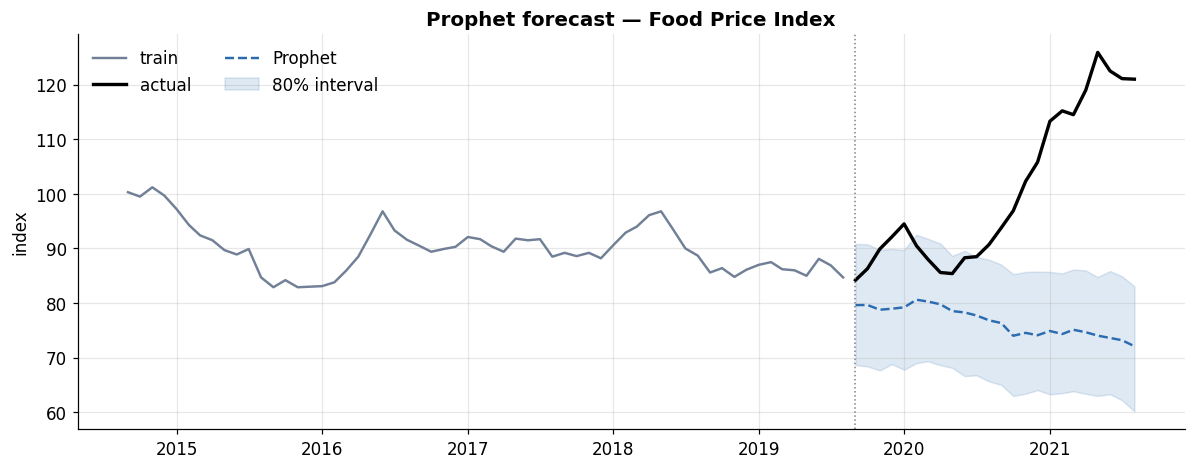

{'model': 'Prophet', 'MAE': np.float64(24.0), 'RMSE': np.float64(29.062), 'MAPE%': np.float64(22.11)}


In [14]:
pdf = pd.DataFrame({"ds": train.index, "y": train.values})
prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                  daily_seasonality=False, seasonality_mode="multiplicative")
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    prophet.fit(pdf)
future = prophet.make_future_dataframe(periods=H, freq="MS")
pf = prophet.predict(future)

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(train.index[-60:], train.iloc[-60:], color=PALETTE[5], label="train")
ax.plot(test.index, test, color="black", lw=2.2, label="actual")
tail = pf.iloc[-H:]
ax.plot(test.index, tail["yhat"].values, color=PALETTE[0], ls="--", label="Prophet")
ax.fill_between(test.index, tail["yhat_lower"].values, tail["yhat_upper"].values,
                color=PALETTE[0], alpha=0.15, label="80% interval")
ax.axvline(test.index[0], color="grey", lw=1, ls=":")
ax.set_title("Prophet forecast — Food Price Index")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()
prophet_fc = pf["yhat"].iloc[-H:].values
print(score("Prophet", test, prophet_fc))

Prophet's great convenience is the **automatic component breakdown** — trend with
detected changepoints, plus the seasonal shape — which makes it easy to explain a
forecast to non-specialists.

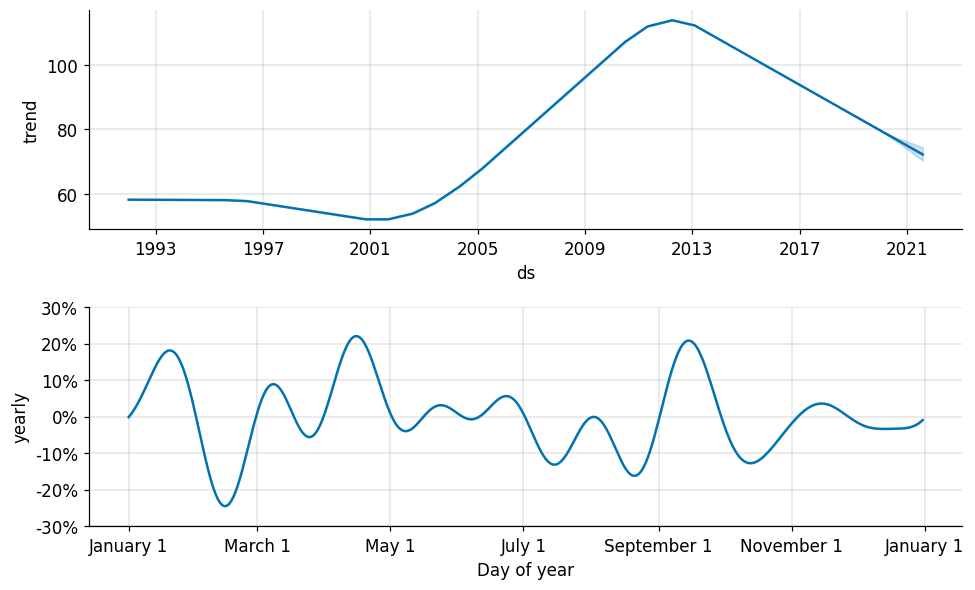

In [15]:
comp_fig = prophet.plot_components(pf)
comp_fig.set_size_inches(9, 5.5)
plt.tight_layout(); plt.show()

The trend panel shows Prophet's piecewise-linear fit bending at detected
changepoints; the yearly panel is the learned seasonal shape. On this dataset the
seasonal amplitude is again modest — the same story every method has told.

## 7. Benchmark — advanced methods vs. the prior winners

We add the point-forecasting members of this part — **Unobserved Components**,
**VAR**, and **Prophet** — to the same 24-month Food Price Index hold-out, next to
Part 3's ETS, Part 4's ARIMA, and the Drift baseline.

For the **VAR** (fitted on log-returns) we forecast the food-return path and
**reconstruct the level** by cumulating from the last observed value — the honest
way to score a differenced model on the original scale.

In [16]:
p = var_res.k_ar
var_fc_ret = var_res.forecast(sys_tr.values[-p:], steps=H)[:, 0] / 100.0  # food log-returns
last_log = sys_levels["Food_Price_Index"].iloc[-H - 1]
var_level = np.exp(last_log + np.cumsum(var_fc_ret))

drift = train.iloc[-1] + (train.iloc[-1]-train.iloc[0])/(len(train)-1) * np.arange(1, H+1)
ets = ETSModel(train, error="mul", trend="add", damped_trend=True,
               initialization_method="estimated").fit(disp=False).forecast(H)
arima110 = ARIMA(train, order=(1,1,0)).fit().get_forecast(H).predicted_mean

board = pd.DataFrame([
    score("Drift [baseline]",            test, drift),
    score("ETS(M,Ad,N) [Part 3]",        test, ets.values),
    score("ARIMA(1,1,0) [Part 4]",       test, arima110.values),
    score("Unobserved Components",       test, uc_mean.values),
    score("VAR(food,energy,urea)",       test, var_level),
    score("Prophet",                     test, prophet_fc),
]).sort_values("RMSE").reset_index(drop=True)
board

,model,MAE,RMSE,MAPE%
0,Drift [baseline],14.899,20.090,13.29
1,"VAR(food,energy,urea)",16.286,21.157,14.68
2,"ARIMA(1,1,0) [Part 4]",17.563,22.550,15.89
3,"ETS(M,Ad,N) [Part 3]",18.834,23.806,17.12
4,Unobserved Components,22.124,28.012,20.11
5,Prophet,24.000,29.062,22.11


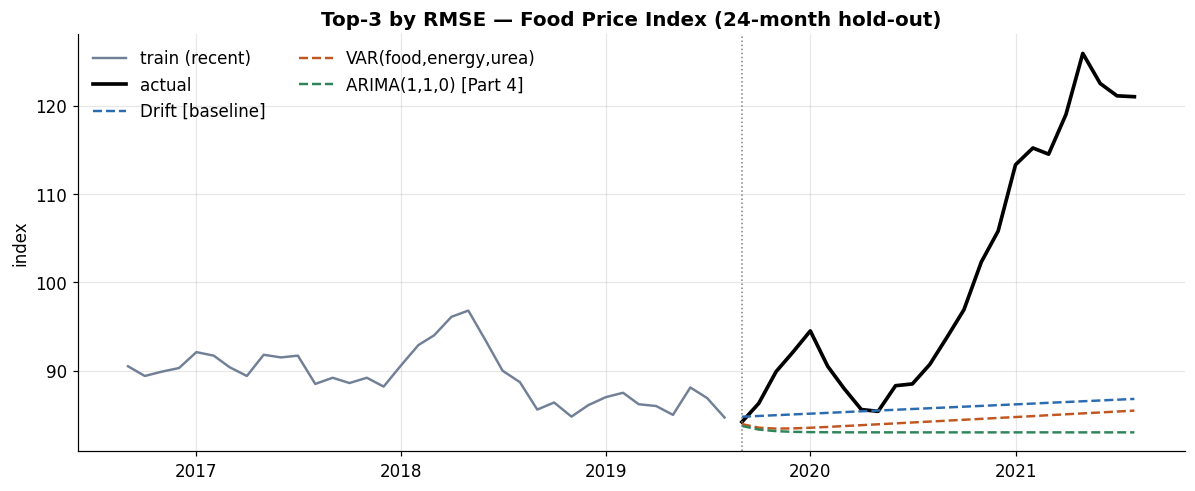

In [17]:
series_map = {"VAR(food,energy,urea)": var_level, "Unobserved Components": uc_mean.values,
              "Prophet": prophet_fc, "ETS(M,Ad,N) [Part 3]": ets.values,
              "ARIMA(1,1,0) [Part 4]": arima110.values, "Drift [baseline]": np.asarray(drift)}
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(train.index[-36:], train.iloc[-36:], color=PALETTE[5], label="train (recent)")
ax.plot(test.index, test, color="black", lw=2.4, label="actual")
for name, c in zip(board["model"].head(3), PALETTE):
    ax.plot(test.index, series_map[name], color=c, ls="--", label=name)
ax.axvline(test.index[0], color="grey", lw=1, ls=":")
ax.set_title(f"Top-3 by RMSE — Food Price Index ({H}-month hold-out)")
ax.set_ylabel("index"); ax.legend(frameon=False, ncol=2)
plt.tight_layout(); plt.show()

The honest reading:

- The **VAR** is the strongest *model* here — using energy's and urea's dynamics
  helps a little, edging out the univariate ETS/ARIMA — but it still sits beside
  the **Drift** baseline, because none of these methods foresees the 2020–21 surge.
- **Unobserved Components** and **Prophet** score *worse* than the simpler models:
  their explicit trend+seasonal structure is confidently projected in the wrong
  direction across the shock. More structure is not automatically better.
- The consistent verdict across Parts 3–5 is that this shock-driven series has
  **little exploitable structure** at a 24-month horizon — a conclusion each family
  reaches independently, which is itself the finding.

Each advanced tool earns its place for a *different* reason than raw accuracy here:
**GARCH** for honest risk/intervals, **VAR/VECM** for understanding
interdependence and equilibria, **state-space** for interpretable evolving
components, **Prophet** for fast, explainable defaults.

## 8. Exercises

1. **GARCH on the VIX.** Fit a GARCH(1,1) to `VIX_Index` log-returns. Is
   volatility more or less persistent (α+β) than for food prices?
2. **Components model.** Fit an Unobserved Components model with a stochastic
   **cycle** added to `Energy_Price_Index`. Does the cycle capture the boom/bust?
3. **Bigger VAR.** Build a 4-variable VAR (add `Maize_Price`) and re-run the
   Granger tests. Do any new predictive links appear?
4. **VECM forecast.** Use the fitted fertilizer VECM to forecast `Urea_Price` 24
   months ahead; reconstruct the level and compare RMSE to an ARIMA on Urea alone.
5. **Prophet changepoints.** Refit Prophet with `changepoint_prior_scale=0.5`
   (more flexible trend). Does the more reactive trend help or hurt the hold-out?

In [18]:
# --- Solution to Exercise 1 ---
vix_ret = 100 * np.log(df["VIX_Index"]).diff().dropna()
gv = arch_model(vix_ret, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
food_pers = garch.params["alpha[1]"] + garch.params["beta[1]"]
vix_pers  = gv.params["alpha[1]"] + gv.params["beta[1]"]
print(f"Volatility persistence (α+β):  Food = {food_pers:.3f}   VIX = {vix_pers:.3f}")
print("More persistent volatility:", "VIX" if vix_pers > food_pers else "Food")

Volatility persistence (α+β):  Food = 0.650   VIX = 1.000
More persistent volatility: VIX


## 9. Key takeaways

- **GARCH** models a **time-varying variance** (volatility clustering) that ARIMA
  assumes away — essential for risk and realistic intervals; check need with the
  **ARCH-LM** test and verify the standardized residuals are clean afterwards.
- **State-space / Unobserved Components** express a series as evolving hidden
  states estimated by the **Kalman filter** — a model-based decomposition that
  generalizes ETS and ARIMA and yields interpretable components with uncertainty.
- **VAR** models a **system** of stationary series; **impulse responses** trace how
  shocks propagate, and **Granger causality** tests predictive precedence — which
  is *not* mechanism, and can run in a surprising direction.
- **Cointegration** (Engle–Granger, Johansen) detects a **long-run equilibrium**
  between non-stationary series; when present, model it with a **VECM**, not by
  blind differencing.
- **Prophet** is a robust, decomposable additive model with automatic changepoints
  and seasonality — an excellent explainable default, not automatically the most
  accurate.
- On our shock-driven hold-out the **VAR** narrowly leads the models while still
  matching the baseline; the durable lesson is that structure must be *justified*,
  and each advanced tool answers a different question than "lowest RMSE."

### What's next — Part 6: Evaluation, Backtesting & Baselines
We have quietly relied on a single train/test split for five parts. Part 6 makes
evaluation **rigorous**: proper time-series cross-validation (expanding vs. sliding
windows), **walk-forward backtesting**, the leakage traps that invalidate results,
and the full metric set (MASE, sMAPE, pinball loss for intervals). It is the
foundation the machine-learning and deep-learning parts (7–10) will stand on.